<a href="https://colab.research.google.com/github/BenjaminNaveas/EvaluacionU1_Naveas_Benjamin/blob/main/EvaluacionU1_Naveas_Benjaminn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IEI-097 MINERÍA DE DATOS · UNIDAD I
## Evaluación Final Unidad I — Proyecto CRISP-DM

* **Nombre completo:** Benjamín Naveas
* **Carrera / Sede / Sección:** Ingeniería en Informática / Instituto Profesional Santo Tomás, Sede Arica
* **Dataset elegido:** Telco Customer Churn (Kaggle, IBM) — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

## **Parte A — El problema**

**Fase CRISP-DM:** Comprensión del Negocio (*Business Understanding*)

**Contexto:** el dataset pertenece a una empresa de telecomunicaciones que vende telefonía e internet. Cada fila es un cliente, con sus datos demográficos, los servicios contratados, su información de cuenta y si abandonó la compañía en el último mes (*Churn*). Lo usarían las áreas de retención y marketing.

**Objetivo:** identificar qué perfiles de clientes se asocian con la cancelación del servicio, para decidir **a quiénes dirigir campañas preventivas de fidelización y descuentos**.

**Por qué minería de datos:** la fuga tiene causas combinadas (por ejemplo tipo de contrato + tecnología de internet + antigüedad). Una consulta o un promedio entrega una cifra global (≈27 % de fuga), pero no revela *qué combinaciones* de características concentran el riesgo. Las reglas de asociación y el árbol de decisión descubren esas combinaciones y ordenan qué variables pesan más.

## **Parte B — Los datos**

**Fase CRISP-DM:** Comprensión de los Datos (*Data Understanding*)

**Fuente:** *Telco Customer Churn*, conjunto de datos de ejemplo de IBM publicado en Kaggle (usuario BlastChar). Enlace: https://www.kaggle.com/datasets/blastchar/telco-customer-churn. La licencia es la que indica la ficha del dataset en Kaggle (ver Parte G). El `customerID` es un código anónimo, no hay nombres ni datos sensibles identificables.

In [ ]:
import os, subprocess, sys
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# mlxtend suele venir instalado en Colab; si no, se instala.
try:
    import mlxtend
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "mlxtend"])

# Carga: usa el archivo local (subido a Colab) y, si no existe, lo descarga del repositorio.
RUTA = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
URL = "https://raw.githubusercontent.com/BenjaminNaveas/EvaluacionU1_Naveas_Benjamin/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(RUTA if os.path.exists(RUTA) else URL)

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.head())

Dimensiones del dataset: 7043 filas y 21 columnas.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Interpretación:** el dataset tiene **7.043 clientes (filas) y 21 columnas**, dentro del rango pedido (500–50.000 filas). Las primeras filas muestran una mezcla de variables categóricas (contrato, servicio de internet, método de pago), numéricas (`tenure`, `MonthlyCharges`) y la variable objetivo `Churn`. Además hay 18 columnas de tipo texto (`object`), una de ellas `TotalCharges`, que debería ser numérica (se corrige en la Parte C).

**Diccionario de 10 atributos:**

| # | Atributo | Tipo | Por qué es importante para el objetivo |
|---|---|---|---|
| 1 | `customerID` | Texto (identificador) | Identifica a cada cliente; permite contar y acciones de contacto, pero no aporta patrones (se descarta del modelado). |
| 2 | `gender` | Categórica | Permite comprobar si el género influye en la fuga o si no hay sesgo demográfico. |
| 3 | `SeniorCitizen` | Binaria (0/1) | Segmenta a adultos mayores, que podrían necesitar planes o atención distinta. |
| 4 | `tenure` | Numérica (meses) | Antigüedad del cliente; indica si el riesgo de fuga cambia con el tiempo en la empresa. |
| 5 | `InternetService` | Categórica (DSL, Fiber optic, No) | Muestra si alguna tecnología concentra insatisfacción y fuga. |
| 6 | `Contract` | Categórica (mensual, 1 año, 2 años) | Mide el compromiso del cliente; es clave para detectar fuga a corto plazo. |
| 7 | `PaymentMethod` | Categórica | Permite ver si los pagos automáticos retienen más que los manuales. |
| 8 | `MonthlyCharges` | Numérica (monto) | Factor económico: ayuda a ver si pagar más se asocia a irse. |
| 9 | `TotalCharges` | Numérica (monto; viene como texto) | Valor acumulado del cliente; complementa la antigüedad para medir su valor. |
| 10 | `Churn` | Categórica (Yes/No) — **variable objetivo** | Es lo que queremos explicar: si el cliente abandonó la empresa. |

## **Parte C — Exploración y preparación (EDA)**

**Fase(s) CRISP-DM:** Comprensión de los Datos (exploración) y Preparación de los Datos (limpieza y descartes).

In [ ]:
# 1. Estructura y tipos de datos (datos originales)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Interpretación:** `info()` dice que no hay nulos, pero eso es engañoso: `TotalCharges` aparece como `object` (texto) aunque debería ser numérica. Probablemente hay celdas con espacios en blanco que Pandas no cuenta como nulos. Lo verifico a continuación.

In [ ]:
# 2. Calidad: duplicados y valores problemáticos en TotalCharges
print("Filas duplicadas:", df.duplicated().sum())

total_num = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Valores no numéricos en TotalCharges:", total_num.isna().sum())
print("\nFilas problemáticas:")
display(df.loc[total_num.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]])

Filas duplicadas: 0
Valores no numéricos en TotalCharges: 11

Filas problemáticas:


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


**Interpretación:** no hay filas duplicadas. En cambio, **11 clientes tienen `TotalCharges` en blanco**. Todos tienen `tenure = 0`: son clientes recién contratados que aún no reciben su primera facturación, y ninguno ha abandonado (`Churn = No`). Es decir, el vacío no es un error aleatorio, sino que refleja que aún no hay cobros acumulados.

In [ ]:
# 3. Preparación: convertir TotalCharges, eliminar las 11 filas y descartar el identificador
datos = df.copy()
datos["TotalCharges"] = pd.to_numeric(datos["TotalCharges"], errors="coerce")
print("Nulos tras convertir:", datos["TotalCharges"].isna().sum())

datos = datos.dropna(subset=["TotalCharges"])
datos = datos.drop(columns="customerID")
print(f"Dimensiones tras la limpieza: {datos.shape[0]} filas y {datos.shape[1]} columnas.")

Nulos tras convertir: 11
Dimensiones tras la limpieza: 7032 filas y 20 columnas.


**Decisiones de limpieza y su justificación:**
* **Convertir `TotalCharges` a número:** el modelo y las estadísticas necesitan un tipo numérico; los espacios en blanco pasan a nulo.
* **Eliminar las 11 filas con `TotalCharges` nulo:** son solo el 0,16 % de los datos, no tienen cobros que analizar y ninguna se fugó, por lo que eliminarlas no sesga el resultado. Quedan 7.032 clientes.
* **Descartar `customerID`:** es un código único; el árbol lo usaría para memorizar clientes en vez de encontrar patrones generales.

In [ ]:
# 4. Estadística descriptiva (variables numéricas) y variables categóricas
display(datos.describe().round(2))
print("\nValores únicos por variable categórica:")
print(datos.select_dtypes(include="object").nunique().to_string())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00,7032.00
mean,0.16,32.42,64.80,2283.30
std,0.37,24.55,30.09,2266.77
min,0.00,1.00,18.25,18.80
25%,0.00,9.00,35.59,401.45
50%,0.00,29.00,70.35,1397.48
75%,0.00,55.00,89.86,3794.74
max,1.00,72.00,118.75,8684.80



Valores únicos por variable categórica:
gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
Churn               2


**Interpretación:** la antigüedad (`tenure`) va de 1 a 72 meses (media ≈ 32); el cobro mensual va de 18,25 a 118,75 (media ≈ 64,8); `TotalCharges` llega a 8.684,8, con una desviación estándar alta (≈ 2.267) porque depende de cuánto tiempo lleva el cliente. Los rangos son coherentes: no hay valores negativos ni cifras imposibles. `SeniorCitizen` tiene media 0,16, es decir, solo ≈16 % son adultos mayores. Las variables categóricas tienen pocas categorías (2 a 4), por lo que son fáciles de trabajar.

       clientes  porcentaje
Churn                      
No         5163        73.4
Yes        1869        26.6


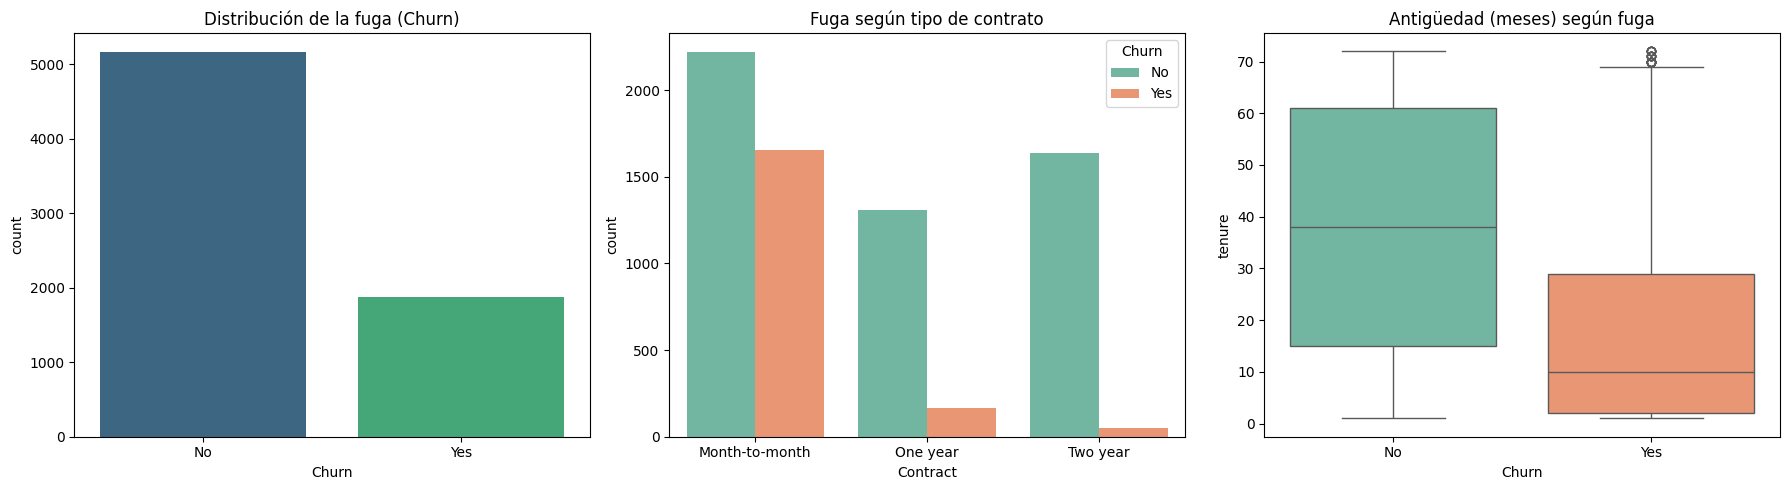


Tasa de fuga por contrato (%):
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8


In [ ]:
# 5. Distribución de la variable objetivo
conteo = datos["Churn"].value_counts()
porc = datos["Churn"].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({"clientes": conteo, "porcentaje": porc}))

# 6. Visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=datos, x="Churn", hue="Churn", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Distribución de la fuga (Churn)")

sns.countplot(data=datos, x="Contract", hue="Churn", palette="Set2", ax=axes[1])
axes[1].set_title("Fuga según tipo de contrato")

sns.boxplot(data=datos, x="Churn", y="tenure", hue="Churn", palette="Set2", legend=False, ax=axes[2])
axes[2].set_title("Antigüedad (meses) según fuga")

plt.tight_layout()
plt.show()

print("\nTasa de fuga por contrato (%):")
print((datos.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)).round(1).to_string())

**Interpretación de las visualizaciones y hallazgos del EDA:**
1. **Desbalance de clases:** hay 73,4 % de clientes que se quedan y 26,6 % que se van. Es un desbalance moderado y normal en retención; significa que debemos buscar los patrones de ese ~27 % que se va, y que un modelo que dijera siempre «No» ya acertaría 73 % sin aprender nada útil.
2. **Contrato:** la fuga se concentra en los contratos mensuales: **42,7 %** se va, contra 11,3 % en contrato de 1 año y solo **2,8 %** en el de 2 años. El contrato largo funciona como barrera de retención.
3. **Antigüedad:** los clientes que se fugan tienen una antigüedad mucho menor (la caja del gráfico está más abajo), es decir, **se van sobre todo en los primeros meses**; los clientes antiguos tienden a quedarse.
4. **Calidad de datos:** el único problema fue `TotalCharges` como texto con 11 vacíos (tratado arriba). No hay duplicados ni valores fuera de rango.

## **Parte D — Reglas de asociación**

**Fase CRISP-DM:** Preparación de los Datos (discretización y *One-Hot*) y Modelado (Apriori).

**Preparación:** Apriori trabaja con ítems presentes o ausentes en cada registro. Por eso las variables numéricas se **discretizan** en tramos con `pd.qcut` (3 grupos con igual cantidad de clientes) y luego todas las columnas se transforman a 0/1 con *One-Hot Encoding*.

**Columnas elegidas (5):** `Contract`, `InternetService`, `Tenure_Tramos` (de `tenure`), `Cobro_Tramos` (de `MonthlyCharges`) y `Churn`. Las elegí porque el EDA mostró que contrato y antigüedad se relacionan con la fuga, y porque tecnología de internet y nivel de cobro son las variables de negocio que la empresa puede modificar con ofertas.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

d = datos.copy()
d["Tenure_Tramos"] = pd.qcut(d["tenure"], q=3, labels=["Corto", "Medio", "Largo"])
d["Cobro_Tramos"] = pd.qcut(d["MonthlyCharges"], q=3, labels=["Bajo", "Medio", "Alto"])

# Qué significa cada tramo
print("Tramos de antigüedad (meses):")
print(d.groupby("Tenure_Tramos", observed=True)["tenure"].agg(["min", "max"]).to_string())
print("\nTramos de cobro mensual:")
print(d.groupby("Cobro_Tramos", observed=True)["MonthlyCharges"].agg(["min", "max"]).to_string())

columnas_apriori = ["Contract", "InternetService", "Tenure_Tramos", "Cobro_Tramos", "Churn"]
df_binario = pd.get_dummies(d[columnas_apriori]).astype(bool)
print("\nMatriz binaria:", df_binario.shape)

Tramos de antigüedad (meses):
               min  max
Tenure_Tramos          
Corto            1   14
Medio           15   47
Largo           48   72

Tramos de cobro mensual:
                min     max
Cobro_Tramos               
Bajo          18.25   50.40
Medio         50.45   84.00
Alto          84.05  118.75

Matriz binaria: (7032, 14)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Interpretación:** `qcut` generó tres tramos de antigüedad: **Corto** (1–14 meses), **Medio** (15–47) y **Largo** (48–72); y tres de cobro: **Bajo** (hasta 50,40), **Medio** (50,45–84,00) y **Alto** (desde 84,05). Cada tramo reúne ≈ un tercio de los clientes. Tras el *One-Hot*, cada categoría es una columna verdadero/falso (por ejemplo `Contract_Month-to-month`), que es el formato que exige Apriori.

In [ ]:
# Prueba de distintos valores de los parámetros
def reglas_churn(min_support, min_lift):
    fi = apriori(df_binario, min_support=min_support, use_colnames=True)
    rl = association_rules(fi, metric="lift", min_threshold=min_lift)
    rl_churn = rl[rl["consequents"] == frozenset({"Churn_Yes"})]
    return fi, rl, rl_churn

filas = []
for s in [0.05, 0.10, 0.20]:
    for l in [1.2, 1.5, 2.0]:
        fi, rl, rc = reglas_churn(s, l)
        filas.append({"min_support": s, "min_lift": l, "itemsets frecuentes": len(fi),
                      "reglas totales": len(rl), "reglas con consecuente Churn=Yes": len(rc)})
display(pd.DataFrame(filas))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,min_support,min_lift,itemsets frecuentes,reglas totales,reglas con consecuente Churn=Yes
0,0.05,1.2,217,904,22
1,0.05,1.5,217,644,18
2,0.05,2.0,217,386,8
3,0.10,1.2,84,146,7
4,0.10,1.5,84,92,5
5,0.10,2.0,84,40,1
6,0.20,1.2,32,24,1
7,0.20,1.5,32,14,1
8,0.20,2.0,32,8,0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

**Interpretación de la variación de parámetros:**
* **`min_support`** controla qué tan frecuente debe ser un patrón. Con 0,20 casi no quedan reglas hacia la fuga (los patrones de riesgo son minoritarios); con 0,10 quedan muy pocas; con **0,05** (≈ 350 clientes, tamaño suficiente para una campaña) aparecen más combinaciones interesantes, como «Fibra + Mensual + Antigüedad corta», que con 0,10 se perdía por muy poco.
* **`min_lift`** controla cuánto más probable debe ser la fuga que en un cliente cualquiera. Con 1,2 hay demasiadas reglas, algunas débiles; con 2,0 quedan pocas pero muy fuertes. **1,5** es un equilibrio: exige que el riesgo sea al menos 50 % mayor que el promedio.
* **Parámetros elegidos: `min_support = 0.05` y `min_lift = 1.5`.**

In [ ]:
fi, rl, rc = reglas_churn(0.05, 1.5)
# Reglas con consecuente Churn=Yes; se muestran las de mayor lift con confianza >= 0.5 y soporte razonable
tabla = rc[rc["confidence"] >= 0.5].sort_values("lift", ascending=False)[["antecedents", "support", "confidence", "lift"]].copy()
tabla["antecedents"] = tabla["antecedents"].apply(lambda s: " + ".join(sorted(s)))
pd.set_option("display.max_colwidth", 100)
display(tabla.head(15).round(3).reset_index(drop=True))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,support,confidence,lift
0,Contract_Month-to-month + InternetService_Fiber optic + Tenure_Tramos_Corto,0.098,0.698,2.625
1,InternetService_Fiber optic + Tenure_Tramos_Corto,0.099,0.694,2.610
2,Cobro_Tramos_Medio + Contract_Month-to-month + InternetService_Fiber optic + Tenure_Tramos_Corto,0.055,0.661,2.487
3,Cobro_Tramos_Medio + InternetService_Fiber optic + Tenure_Tramos_Corto,0.055,0.660,2.482
4,Cobro_Tramos_Medio + Contract_Month-to-month + InternetService_Fiber optic,0.071,0.572,2.153
5,Contract_Month-to-month + InternetService_Fiber optic,0.165,0.546,2.054
6,Cobro_Tramos_Medio + Contract_Month-to-month + Tenure_Tramos_Corto,0.069,0.543,2.044
7,Cobro_Tramos_Medio + InternetService_Fiber optic,0.072,0.541,2.037
8,Cobro_Tramos_Alto + Contract_Month-to-month + InternetService_Fiber optic,0.094,0.528,1.986
9,Cobro_Tramos_Alto + Contract_Month-to-month,0.094,0.526,1.978


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

**Tabla de reglas interpretadas** (todas con consecuente `Churn = Yes`, según la tabla anterior):

| # | Regla | Support | Confidence | Lift |
|---|---|---|---|---|
| 1 | {Fibra óptica, Contrato mensual} → Churn | 0,165 | 0,546 | 2,05 |
| 2 | {Fibra óptica, Contrato mensual, Antigüedad corta} → Churn | 0,098 | 0,698 | 2,62 |
| 3 | {Cobro alto, Contrato mensual} → Churn | 0,094 | 0,526 | 1,98 |
| 4 | {Antigüedad corta, Contrato mensual} → Churn | 0,154 | 0,508 | 1,91 |

1. **Fibra óptica + contrato mensual.** El 16,5 % de los clientes cumple la condición (support); de ellos, el **54,6 % se fuga** (confidence), y la fuga es **2,05 veces** más probable que en un cliente cualquiera (lift > 1: asociación positiva real, no casualidad por frecuencia). *Decisión:* ofrecer a este grupo un descuento para migrar de contrato mensual a anual.
2. **Fibra + mensual + antigüedad corta.** Es el perfil más riesgoso: **69,8 %** se va y el lift sube a **2,62**. Representa ≈ 9,8 % de los clientes. *Decisión:* intervenir en los primeros meses con contacto proactivo y revisión de calidad del servicio de fibra para clientes nuevos.
3. **Cobro alto + contrato mensual.** El 9,4 % de los clientes está en este grupo; el 52,6 % se fuga (lift 1,98). Pagar mucho sin compromiso de permanencia se asocia al abandono. *Decisión:* revisar precios o ofrecer planes anuales con descuento para quienes pagan más.
4. **Antigüedad corta + contrato mensual.** Cubre 15,4 % de la base; el 50,8 % se va (lift 1,91). *Decisión:* programa de bienvenida (*onboarding*) con beneficios durante los primeros meses.

**Cuidado al interpretar:** estas reglas muestran **asociación, no causalidad**: no prueban que la fibra o el contrato mensual *causen* la fuga, solo que ocurren juntos con más frecuencia.

## **Parte E — Árbol de decisión**

**Fase CRISP-DM:** Preparación de los Datos (selección de columnas y *One-Hot*) y Modelado (árbol).

**Variable objetivo:** `Churn` (categórica, 2 clases: Yes / No), la misma de la pregunta de negocio.

**Columnas descartadas:** `customerID` (identificador, ya eliminado en la Parte C). No usé las columnas de tramos creadas para las reglas de asociación, porque duplican información de `tenure` y `MonthlyCharges`, que el árbol puede dividir directamente en el punto de corte óptimo.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

a = datos.copy()
y = (a["Churn"] == "Yes").astype(int)          # 1 = Fuga, 0 = No fuga
X = pd.get_dummies(a.drop(columns="Churn"))    # One-Hot de las categóricas

# Revisión de posible fuga de información: ¿alguna columna es casi equivalente al objetivo?
corr = X.astype(float).corrwith(y).abs().sort_values(ascending=False)
print("Mayores correlaciones absolutas con Churn:")
print(corr.head(5).round(3).to_string())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Mayores correlaciones absolutas con Churn:
Contract_Month-to-month        0.405
tenure                         0.354
OnlineSecurity_No              0.342
TechSupport_No                 0.337
InternetService_Fiber optic    0.307


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Interpretación (fuga de información):** se revisa si alguna columna es casi equivalente al objetivo (*data leakage*). Una forma simple es medir su correlación con `Churn`. La mayor es `Contract_Month-to-month` con ≈ 0,40, lejos de 1. Por lo tanto **ninguna columna entrega la respuesta directamente**: las relaciones son reales pero parciales y el árbol puede aportar conocimiento.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

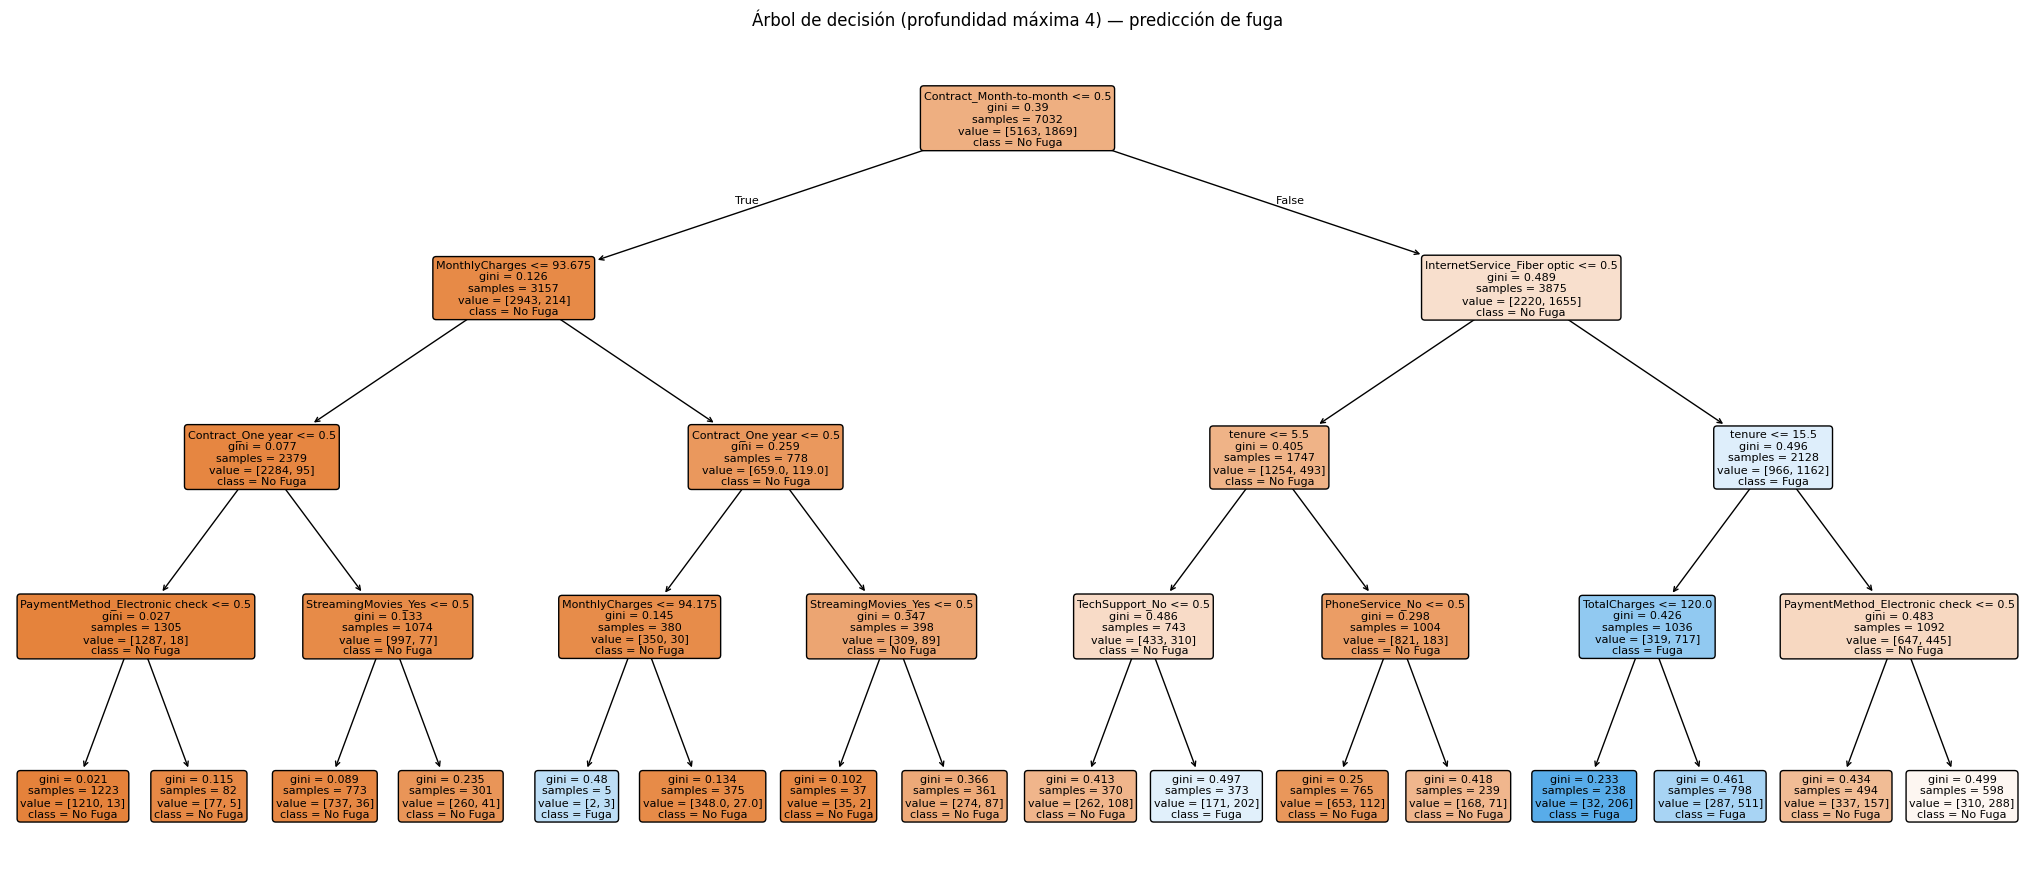

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol.fit(X, y)

plt.figure(figsize=(26, 11))
plot_tree(arbol, feature_names=list(X.columns), class_names=["No Fuga", "Fuga"],
          filled=True, rounded=True, fontsize=8, proportion=False)
plt.title("Árbol de decisión (profundidad máxima 4) — predicción de fuga")
plt.show()

**Lectura del gráfico:** cada nodo muestra la condición de corte, el índice *gini* (impureza: 0 = nodo puro), el número de clientes (*samples*), cuántos hay de cada clase (*value*) y la clase mayoritaria. El color indica la clase: naranja para «No fuga» y azul para «Fuga», y es más intenso mientras más puro es el nodo.

In [ ]:
print(export_text(arbol, feature_names=list(X.columns)))

imp = pd.Series(arbol.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nImportancia de atributos (top 5):")
print(imp.head(5).round(3).to_string())

# Resumen de las hojas: tamaño y % de fuga real
hojas = arbol.apply(X)
res = pd.DataFrame({"hoja": hojas, "fuga": y}).groupby("hoja")["fuga"].agg(clientes="count", pct_fuga="mean")
res["pct_fuga"] = (res["pct_fuga"] * 100).round(1)
print("\nHojas del árbol (clientes y % real de fuga):")
print(res.sort_values("pct_fuga", ascending=False).to_string())

|--- Contract_Month-to-month <= 0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- Contract_One year <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Contract_One year >  0.50
|   |   |   |--- StreamingMovies_Yes <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- StreamingMovies_Yes >  0.50
|   |   |   |   |--- class: 0
|   |--- MonthlyCharges >  93.67
|   |   |--- Contract_One year <= 0.50
|   |   |   |--- MonthlyCharges <= 94.17
|   |   |   |   |--- class: 1
|   |   |   |--- MonthlyCharges >  94.17
|   |   |   |   |--- class: 0
|   |   |--- Contract_One year >  0.50
|   |   |   |--- StreamingMovies_Yes <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- StreamingMovies_Yes >  0.50
|   |   |   |   |--- class: 0
|--- Contract_Month-to-month >  0.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- tenure <= 5.50
|   |   |   |--- 

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

**Atributo raíz:** es `Contract_Month-to-month`. El algoritmo evalúa todas las variables y elige la que separa mejor a los clientes que se fugan de los que se quedan (mayor reducción de gini). Coincide con el EDA, donde el contrato era el factor que más diferenciaba la fuga (42,7 % mensual vs 2,8 % a 2 años). Es también el atributo con mayor importancia (≈ 0,55), seguido de `InternetService_Fiber optic` y `tenure` (≈ 0,16 cada uno).

**Caminos traducidos a reglas de negocio** (los porcentajes salen de la tabla de hojas):
1. **Mayor riesgo:** SI el contrato es mensual **Y** el internet es fibra óptica **Y** la antigüedad es de 15 meses o menos → **Fuga**. Son ≈ 1.036 clientes (≈ 15 % de la base) con fuga real de **64 % a 87 %**, según el tramo de `TotalCharges`. *Decisión:* es el segmento prioritario para retención: contacto temprano, revisión de calidad de la fibra y oferta de contrato anual.
2. **Mayor lealtad:** SI el contrato **no** es mensual **Y** el cobro mensual es de 93,67 o menos **Y** el contrato es de 2 años **Y** no paga con *electronic check* → **No fuga**. Son 1.223 clientes con solo **1,1 %** de fuga. *Decisión:* grupo de bajo riesgo; no gastar descuentos de retención aquí y, en cambio, ofrecerles ampliaciones de servicio (*up-selling*).
3. **Riesgo sin fibra:** SI el contrato es mensual **Y** NO tiene fibra óptica **Y** la antigüedad es de 5 meses o menos **Y** no tiene soporte técnico → **Fuga**. Son 373 clientes con **54,2 %** de fuga. *Decisión:* ofrecer soporte técnico gratuito o de prueba a clientes nuevos de contrato mensual.

**Qué decisión apoya el árbol:** priorizar a qué clientes dirigir las campañas de retención, ordenándolos por perfil de riesgo, y definir qué acciones aplicar a cada grupo.

**Profundidad máxima 4:** mantiene el árbol legible para una persona (como máximo 4 condiciones por camino) y evita el sobreajuste. En un árbol mucho más profundo las hojas se harían cada vez más pequeñas y específicas: ya en este árbol hay una hoja con solo **5 clientes** (cobro mensual entre 93,67 y 94,17), que es un ejemplo de ruido y no de un patrón de negocio. Con más profundidad el árbol memorizaría casos particulares y generalizaría peor.

## **Parte F — Síntesis y proceso CRISP-DM**

**Fase CRISP-DM:** esta parte revisa todas (en especial Evaluación y Despliegue).

**Comparación de las dos representaciones**

| | Reglas de asociación | Árbol de decisión |
|---|---|---|
| Tipo de conocimiento | Combinaciones de características que ocurren juntas, con su support, confidence y lift. Son muchas reglas independientes. | Una estructura jerárquica que **clasifica** a cada cliente y ordena qué variables importan primero. |
| Cuándo usarla | Para **explorar** nichos y descubrir combinaciones inesperadas (p. ej. fibra + mensual + cliente nuevo). | Para **segmentar y priorizar** clientes con una regla de decisión completa y fácil de explicar. |
| Variables numéricas | Obliga a discretizar y se pierde precisión. | Las divide sola en el mejor punto de corte (p. ej. tenure ≤ 15,5). |

**Limitaciones con este dataset**
* El **desbalance 73/27** hace que la clase «Fuga» sea minoritaria; los patrones de riesgo afectan a grupos pequeños y un árbol tiende a favorecer a la clase «No».
* El dataset es una **foto de un solo mes**: no hay evolución en el tiempo ni sabemos *por qué* se fue cada cliente.
* Las reglas y el árbol muestran **asociaciones, no causas**; para saber si un descuento realmente retiene hay que probarlo.
* En las reglas, la **discretización en terciles** es arbitraria y depende de los cortes elegidos; y en el árbol las hojas muy pequeñas (como la de 5 clientes) no son confiables.
* El árbol se entrenó con **todos** los datos y no se midió su desempeño, porque no era objetivo de esta actividad; por eso no puede usarse todavía para predecir en producción.

**Tabla de fases CRISP-DM**

| Fase CRISP-DM | Qué hice / qué propondría | Parte |
|---|---|---|
| **1. Comprensión del negocio** | Definí el problema de retención, el objetivo y por qué usar minería de datos. | A |
| **2. Comprensión de los datos** | Carga, diccionario de atributos, estructura, nulos, duplicados, estadística descriptiva y gráficos. | B y C |
| **3. Preparación de los datos** | Convertí `TotalCharges`, eliminé 11 filas y `customerID`, discreticé con `qcut` y apliqué *One-Hot*. | C, D y E |
| **4. Modelado** | Apriori para reglas de asociación y `DecisionTreeClassifier` con profundidad máxima 4. | D y E |
| **5. Evaluación** | Interpreté support, confidence y lift y los caminos del árbol como reglas de negocio; revisé posible fuga de información. *Propuesta:* evaluar el árbol con partición entrenamiento/prueba y métricas como recall de la clase «Fuga». | D, E y F |
| **6. Despliegue** | *Propuesta:* ver abajo. | F y G |

**Propuesta de evaluación y puesta en uso**
1. **Evaluar el modelo:** separar los datos en entrenamiento y prueba, y medir si el árbol detecta bien a los clientes que se fugan (por ejemplo, su recall en la clase «Fuga»), porque acertar solo en «No fuga» no sirve.
2. **Validar con el negocio:** mostrar las reglas a los equipos de retención y marketing para comprobar que tienen sentido y son accionables.
3. **Probar antes de masificar:** hacer un piloto o prueba A/B: ofrecer la campaña (p. ej. descuento por pasar a contrato anual) a un grupo de clientes de alto riesgo y comparar su tasa de fuga con otro grupo similar sin oferta. Así se mide el efecto real de la acción y se calcula si el descuento se paga solo.
4. **Poner en uso:** ejecutar el modelo periódicamente (por ejemplo, cada mes) sobre la base de clientes actual, generar una lista de clientes en riesgo para el CRM y reentrenarlo cuando cambie el comportamiento o los planes de la empresa.

## **Parte G — Autoría y uso de herramientas**

* **Repositorio de GitHub (notebook sincronizado):** https://github.com/BenjaminNaveas/EvaluacionU1_Naveas_Benjamin
* **Cita del dataset:** IBM (conjunto de ejemplo). *Telco Customer Churn* [conjunto de datos]. Publicado en Kaggle por BlastChar. https://www.kaggle.com/datasets/blastchar/telco-customer-churn. Licencia: la indicada en la ficha del dataset en Kaggle (consultada para esta entrega).

**Declaración de autoría:** yo, Benjamín Naveas, declaro que este trabajo es mío y que puedo explicar cada una de sus partes.

**Uso de IA generativa:** utilicé una herramienta de IA generativa (Claude) como apoyo para estructurar el código en `pandas`, `mlxtend` y `scikit-learn`, para revisar errores y para comprobar que los textos coincidieran con las salidas del código. La elección del dataset y del problema, las decisiones de limpieza, la lectura e interpretación de reglas y árbol, y la ubicación de las fases CRISP-DM las revisé y las entiendo, y puedo explicarlas.

**Aprendizaje principal:** aprendí que lo más importante no es ejecutar el algoritmo sino preparar bien los datos (por ejemplo, entender por qué faltaban 11 valores en `TotalCharges`) y traducir los números (support, confidence, lift, caminos del árbol) en decisiones de negocio. También aprendí que estas reglas muestran asociaciones, no causas.